In [1]:
import multiprocessing
import numpy as np
import matplotlib.pyplot as plt
import os
import pinocchio as pin
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from auto_robot_design.description.builder import ParametrizedBuilder, DetailedURDFCreatorFixedEE, MIT_CHEETAH_PARAMS_DICT
from pymoo.core.problem import StarmapParallelization
from pymoo.algorithms.moo.age2 import AGEMOEA2
from auto_robot_design.description.utils import draw_joint_point
from auto_robot_design.optimization.problems import MultiCriteriaProblem
from auto_robot_design.optimization.optimizer import PymooOptimizer
from auto_robot_design.generator.topologies.bounds_preset import get_preset_by_index_with_bounds
from auto_robot_design.optimization.saver import ProblemSaver
from auto_robot_design.generator.branch_generator.updated_generator import Generator2DRotational, GeneratorConnection
from auto_robot_design.generator.branch_generator.graph_scheme import MutationType, MutationCoordinate, SchemeEE, SchemeJoint, SchemeConnectionJoint
from auto_robot_design.kinematics.criterion_agregator import CriteriaAggregator
from auto_robot_design.description.kinematics import JointPoint
from dataclasses import dataclass
from auto_robot_design.utils.configs import get_standard_trajectories
from auto_robot_design.generator.branch_generator.graph_manager import MutableGraphManager
from auto_robot_design.description.utils import draw_joint_point
from auto_robot_design.kinematics.calc_criterion import ActuatedMass, EffectiveInertiaCompute, ImfCompute, ManipCompute, MovmentSurface, NeutralPoseMass, TranslationErrorMSE, ManipJacobian
from auto_robot_design.kinematics.criterion_math import ImfProjections
from auto_robot_design.optimization.rewards.reward_base import PositioningReward, PositioningConstrain, PositioningErrorCalculator, RewardManager
from auto_robot_design.optimization.rewards.jacobian_and_inertia_rewards import HeavyLiftingReward, AccelerationCapability, MeanHeavyLiftingReward, MinAccelerationCapability

from auto_robot_design.utils.configs import inertial_config_two_link_workspace, inertial_config_two_link_six_trajectories, inertial_config_two_link_six_trajectories_v2, jacobian_config_two_link_workspace, jacobian_config_two_link_six_trajectories

Very simple generator.

2


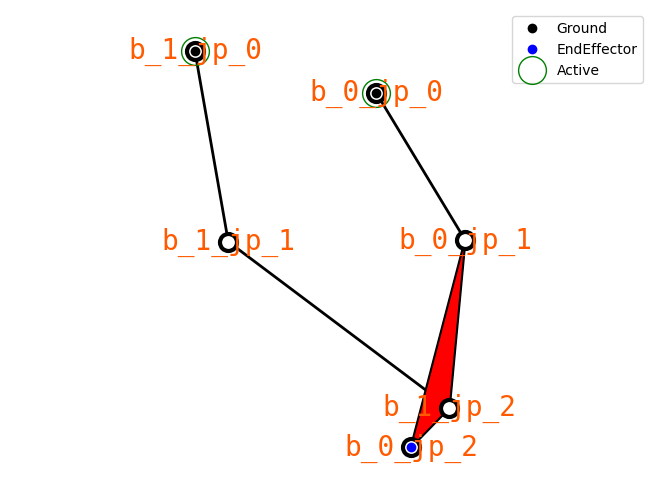

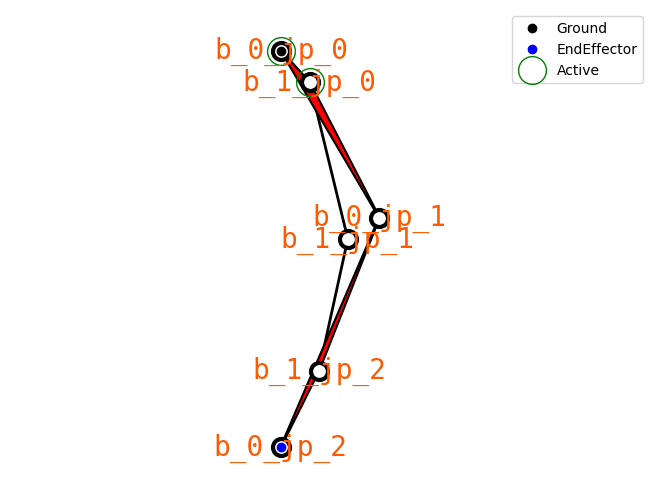

In [10]:
# first step - build branches.
# Main branch consists of two joints and end effector.
generator = Generator2DRotational()
joint = SchemeJoint(name="b_0_j_0", mutation_type=MutationType.ABSOLUTE, mutation_x=MutationCoordinate(
    freeze=0.0), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(freeze=0.0), active=True, attach_ground=True)
generator.add_joint(joint)
joint = SchemeJoint(name="b_0_j_1", mutation_type=MutationType.ABSOLUTE,
                    mutation_x=MutationCoordinate(mutation_origin=0.05, lower_bound=-0.1, upper_bound=0.1), mutation_y = MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.2, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(joint)
ee = SchemeEE(name="b_0_j_2", mutation_x=MutationCoordinate(mutation_origin=0.0, lower_bound=-0.1, upper_bound=0.1), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.4, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(ee)
# Set the possible connections for the main branch, each connection is also a joint and it requires the description of possible mutations.
scheme_connection = SchemeConnectionJoint(name="G",
                                            mutation_type=MutationType.ABSOLUTE,
                                            mutation_x = MutationCoordinate(mutation_origin=-0.2, upper_bound=0.1, lower_bound=-0.1), 
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=0.0, upper_bound=0.2),
                                        active=False, attach_ground=True, connected_to=(0,-1))
connection = GeneratorConnection(scheme_connection, start_open=([1]), end_open=(), connected=None)
generator.add_connection(connection)
scheme_connection = SchemeConnectionJoint(name="CJ_0",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE,
                                            mutation_x = MutationCoordinate(mutation_origin=0, lower_bound=-0.2, upper_bound=0.2),
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=-0.4, upper_bound=0.4),
                                        active=False, attach_ground=False, connected_to=(0, 0))
connection = GeneratorConnection(scheme_connection, start_open=([1]), end_open=(), connected=None)
generator.add_connection(connection)
scheme_connection = SchemeConnectionJoint(name="CJ_1",
                                            mutation_type=MutationType.RELATIVE_PERCENTAGE, 
                                            mutation_x = MutationCoordinate(mutation_origin=0, lower_bound=-0.2, upper_bound=0.2),
                                            mutation_y = MutationCoordinate(freeze=0.0),
                                            mutation_z = MutationCoordinate(mutation_origin=0.0, lower_bound=-0.4, upper_bound=0.4),
                                        active=False, attach_ground=False, connected_to=(0, 1))
connection = GeneratorConnection(scheme_connection, start_open=(), end_open=([1]), connected=None)
generator.add_connection(connection)

# set the secondary branch - each branch has two connections in the start and end, here we have only one additional joint and the result is the two-link branch
generator.create_sub_branch()
joint = SchemeJoint(name="b_1_j_0", mutation_type=MutationType.RELATIVE, mutation_x=MutationCoordinate(mutation_origin=0.0, lower_bound=-0.1, upper_bound=0.1), mutation_y=MutationCoordinate(freeze=0.0), mutation_z=MutationCoordinate(mutation_origin=-0.2, lower_bound=-0.1, upper_bound=0.1))
generator.add_joint(joint, 1)

# build_all_topologies creates the list of possible graph schemes that can be constructed from the declared branches and connections.
generator.build_all_topologies()
print(len(generator.topologies))

topologies = []
for topology in generator.topologies:
    manager = MutableGraphManager(topology)
    manager.build_graph()
    manager.get_mutation_ranges()
    graph = manager.get_random_graph()
    manager.find_active_joints()
    topologies.append(manager)
    patches = []
    for triangle in manager.triangle_links:
        patches.append([triangle,"#FF0000"])
    draw_joint_point(graph, patches_list=patches)
    plt.show()

The builder class converts graphs into the model for simulation. User should provide density and actuator parameters for the builder.
Builder class provides the interface for setting parameters for each jp, and use the "default" value for all remaining jp. 

In [3]:
thickness = MIT_CHEETAH_PARAMS_DICT["thickness"]
actuator = MIT_CHEETAH_PARAMS_DICT["actuator"]
body_density = MIT_CHEETAH_PARAMS_DICT["body_density"]
density = MIT_CHEETAH_PARAMS_DICT["density"]
builder = ParametrizedBuilder(DetailedURDFCreatorFixedEE,
                                  density={"default": density,
                                           "b_0_jp_0": body_density},
                                  thickness={
                                      "default": thickness, "b_0_jp_2": 0.003},
                                  actuator={"default": actuator}
                                  )


CriteriaAggregator is an aggregator class for various quantitative characteristics of a mechanism. For each quantity there is a class that implement the calculation. The keys in the dicts can be used to access the results of the calculations.

In [4]:
# criteria that either calculated without any reference to points, or calculated through the aggregation of values from all points on trajectory
dict_trajectory_criteria = {
    "MASS": NeutralPoseMass(),
    "POS_ERR": TranslationErrorMSE()  # MSE of deviation from the trajectory
}
# criteria calculated for each point on the trajectory
dict_point_criteria = {
    # Impact mitigation factor along the axis
    "IMF": ImfCompute(ImfProjections.Z),
    "MANIP": ManipCompute(MovmentSurface.XZ),
    "Effective_Inertia": EffectiveInertiaCompute(),
    "Actuated_Mass": ActuatedMass(),
    "Manip_Jacobian": ManipJacobian(MovmentSurface.XZ)
}

criteria_aggregator = CriteriaAggregator(
            dict_point_criteria, dict_trajectory_criteria, alg_name="Open_Loop")

Reward manager combines the combines the reward functions and the trajectories at which the rewards are calculated.
For each trajectory we only need to calculate configurations ones, for that reason we add trajectories to the manager class and then set the trajectories from the registered list to the rewards. The trajectories are numpy arrays of points in the world coordinate system.  
For each reward an instance is required that is registered to the manager with the corresponding trajectory id. Each reward requires one or more quantities calculated by the aggregator. The keys registered to the aggregator should be set for rewards.

In [5]:
reward_manager = RewardManager(criteria_aggregator)

trajectories = get_standard_trajectories()

workspace_trajectory = trajectories['workspace']
ground_symmetric_step1 = trajectories['step1']
ground_symmetric_step2 = trajectories['step2']
ground_symmetric_step3 = trajectories['step3']
central_vertical = trajectories['central_vertical']
left_vertical = trajectories['left_vertical']
right_vertical = trajectories['right_vertical']

reward_manager.add_trajectory(ground_symmetric_step1, 0)
reward_manager.add_trajectory(ground_symmetric_step2, 1)
reward_manager.add_trajectory(ground_symmetric_step3, 2)

reward_manager.add_trajectory(central_vertical, 3)
reward_manager.add_trajectory(left_vertical, 4)
reward_manager.add_trajectory(right_vertical, 5)

acceleration_capability = AccelerationCapability(manipulability_key='Manip_Jacobian', trajectory_key="traj_6d", reachability_key="is_reach", actuated_mass_key="Actuated_Mass")
heavy_lifting = HeavyLiftingReward(manipulability_key='Manip_Jacobian', mass_key='MASS', reachability_key="is_reach")

reward_manager.add_reward(acceleration_capability, 0, 1)
reward_manager.add_reward(acceleration_capability, 1, 1)
reward_manager.add_reward(acceleration_capability, 2, 1)

reward_manager.add_reward(heavy_lifting, 3, 1)
reward_manager.add_reward(heavy_lifting, 4, 1)
reward_manager.add_reward(heavy_lifting, 5, 1)

reward_manager.add_trajectory_aggregator([0, 1, 2], 'mean')
reward_manager.add_trajectory_aggregator([3, 4, 5], 'mean')

The trajectory_in_workspace constrain is applied through the mechanism similar to the reward calculation. The calculator has the same interface as a reward and the trajectories that should be in the workspace are registered to the PositioningConstrain object.

In [6]:
    # set up special classes for reward calculations
error_calculator = PositioningErrorCalculator(jacobian_key="Manip_Jacobian")
soft_constrain = PositioningConstrain(error_calculator=error_calculator, points=[ground_symmetric_step1, ground_symmetric_step2, ground_symmetric_step3, central_vertical, left_vertical, right_vertical])


MutableGraphManager for the optimizing topology and the objects for reward calculations are sent to the  MultiCriteriaProblem object which is inherited from pymoo ElementwiseProblem. To start the optimization set the optimization algorithm and construct the pymoo optimizer object.

In [7]:
from auto_robot_design.description.builder import jps_graph2pinocchio_robot, jps_graph2pinocchio_robot_3d_constraints

fixed_robot, free_robot = jps_graph2pinocchio_robot_3d_constraints(graph, builder)

In [8]:
pin.seed(1)
N_PROCESS = 1
population_size = 50
n_generations = 30
topology_idx = 0
gm = topologies[topology_idx]  # Use the specified topology for the optimization
pool = multiprocessing.Pool(N_PROCESS)
runner = StarmapParallelization(pool.starmap)
    # create the problem for the current optimization
problem = MultiCriteriaProblem(gm, builder, reward_manager,
                                soft_constrain, elementwise_runner=runner, Actuator=builder.actuator['default'])

saver = ProblemSaver(problem, f"new_experiment\\topology_{topology_idx}", True)
saver.save_nonmutable()
algorithm = AGEMOEA2(pop_size=population_size, save_history=True)
optimizer = PymooOptimizer(problem, algorithm, saver)

res = optimizer.run(
    True, **{
        "seed": 2,
        "termination": ("n_gen", n_generations),
        "verbose": True
    })

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       50 |      2 |             - |             -
     2 |      100 |      4 |  0.3510454018 |             f
     3 |      150 |      5 |  0.0266158917 |         ideal
     4 |      200 |      9 |  0.4192391911 |         ideal
     5 |      250 |     17 |  0.0372254572 |             f
     6 |      300 |     20 |  0.0273481805 |         ideal
     7 |      350 |     12 |  0.0580346400 |         ideal
     8 |      400 |     17 |  0.1060042143 |         ideal
     9 |      450 |     25 |  0.2212706364 |         ideal
    10 |      500 |     16 |  0.0296475794 |         ideal
    11 |      550 |     21 |  0.0166145751 |         ideal
    12 |      600 |     30 |  0.0305977635 |         ideal
    13 |      650 |     34 |  0.0179262205 |             f
    14 |      700 |     38 |  0.0164778631 |             f
    15 |      750 |     37 |  0.0297936510 |         ideal
    16 |      800 |     50 |  0.0103514156 |            

In [ ]:
pin.seed(1)
N_PROCESS = 1
population_size = 50
n_generations = 30
topology_idx = 1
gm = topologies[topology_idx]  # Use the specified topology for the optimization
pool = multiprocessing.Pool(N_PROCESS)
runner = StarmapParallelization(pool.starmap)
    # create the problem for the current optimization
problem = MultiCriteriaProblem(gm, builder, reward_manager,
                                soft_constrain, elementwise_runner=runner, Actuator=builder.actuator['default'])

saver = ProblemSaver(problem, f"inertial_config_light\\filtered_topologies_50gen_64pop\\topology_{topology_idx}", True)
saver.save_nonmutable()
algorithm = AGEMOEA2(pop_size=population_size, save_history=True)
optimizer = PymooOptimizer(problem, algorithm, saver)

res = optimizer.run(
    True, **{
        "seed": 2,
        "termination": ("n_gen", n_generations),
        "verbose": True
    })

     1 |       50 |      2 |  2.037744E+02 |         ideal
     2 |      100 |      3 |  0.4072944988 |         ideal
     3 |      150 |      7 |  0.6582505043 |         ideal
     4 |      200 |     10 |  0.1322528015 |         ideal
     5 |      250 |      6 |  0.0647989079 |             f
     6 |      300 |     10 |  0.0279323487 |         ideal
     7 |      350 |     10 |  0.000000E+00 |             f
     8 |      400 |     12 |  0.0270011735 |             f
     9 |      450 |     15 |  0.0805454561 |         ideal
    10 |      500 |     15 |  0.0275042142 |             f
    11 |      550 |     14 |  0.0139266523 |             f
    12 |      600 |     16 |  0.1810074226 |         ideal
    13 |      650 |     23 |  0.0518555140 |         ideal
    14 |      700 |     23 |  0.0183311131 |             f
    15 |      750 |     24 |  0.0100022271 |             f
    16 |      800 |     29 |  0.0307241111 |         ideal
    17 |      850 |     27 |  0.0267147428 |         ide